### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)
    

### Data Loading

In [2]:
dat = pd.read_csv('../../data/macromolecular/macromolecules.csv')
dat_flynn = pd.read_csv('../../data/macromolecular/flynn_macromolecules.csv')

dat['N']   *= 0.001
dat['chl'] *= 1000
dat['C']   *= 0.001

dat = dat.merge(dat_flynn.loc[:, ('t', 'ammonium')], on='t')
dat['ammonium'] *= 0.08325909

dat = dat.rename(columns={'N': 'PR', 'ammonium': 'N', 'C': 'CH'})

state_names  = ['CH', 'PR', 'chl', 'N']
state_labels = ['Carbon (CH)', 'Protein (PR)',
                'Chlorophyll (chl)', 'Nutrient (N)']
colors = ['steelblue', 'darkorange', 'green', 'purple']

print(dat.head())
print(f"\nShape: {dat.shape}")

     t        PR      chl        CH         N
0  5.0  0.018571  15.6689  0.124167  0.107238
1  5.5  0.019286  19.0265  0.178333  0.104906
2  6.0  0.045714  20.1457  0.131667  0.104657
3  6.5  0.025714  45.8875  0.172500  0.102076
4  7.0  0.025714  45.8875  0.170000  0.102076

Shape: (35, 5)


### Normalize and build Tensors

In [3]:
t_raw = dat['t'].values.astype(np.float32)
t_min, t_max = t_raw.min(), t_raw.max()
t_norm = (t_raw - t_min) / (t_max - t_min)

scalers = {}
data_scaled = {}
for col in state_names:
    vals = dat[col].values.astype(np.float32)
    vmin, vmax = vals.min(), vals.max()
    scalers[col] = (vmin, vmax)
    data_scaled[col] = (vals - vmin) / (vmax - vmin)

# Observation tensors
t_tensor = tf.constant(t_norm[:, None], dtype=tf.float32)
target   = tf.constant(
    np.column_stack([data_scaled[col] for col in state_names]),
    dtype=tf.float32
)

# Collocation points -- must be a tf.Variable so GradientTape can watch it
t_col = tf.Variable(
    np.linspace(0, 1, 500, dtype=np.float32)[:, None],
    dtype=tf.float32, trainable=False
)
dt_scale = float(t_max - t_min)

print(f"Observation points: {len(t_norm)}")
print(f"Collocation points: {t_col.shape[0]}")


Observation points: 35
Collocation points: 500


### PINN Model

In [10]:
# Prior means for ODE parameters
default_params = {
    'mu': 0.3, 'KN': 0.002, 'CHsyn': 5.0, 'm_ex': 10.0,
    'R_ex': 13.0, 'tau': 10.0, 'b': 0.05, 'CNpro': 6.6
}

def build_pinn(hidden=[64, 64, 64], activation='gelu'):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(1,)))
    for h in hidden:
        model.add(tf.keras.layers.Dense(h, activation=activation))
    model.add(tf.keras.layers.Dense(4, activation='sigmoid'))  # sigmoid output
    return model
   

### Physics Loss

In [11]:
def physics_loss(model, t_col, scalers, dt_scale, ode_params):
    mu, KN, CHsyn, m_ex, R_ex, tau, b, CNpro = ode_params

    CH_min, CH_max = scalers['CH']
    PR_min, PR_max = scalers['PR']
    r_min,  r_max  = scalers['chl']
    N_min,  N_max  = scalers['N']

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t_col)
        out = model(t_col)
        CH = out[:, 0:1] * (CH_max - CH_min) + CH_min
        PR = out[:, 1:2] * (PR_max - PR_min) + PR_min
        r  = out[:, 2:3] * (r_max  - r_min)  + r_min
        N  = out[:, 3:4] * (N_max  - N_min)  + N_min

    dCH_dt = tape.gradient(CH, t_col) / dt_scale
    dPR_dt = tape.gradient(PR, t_col) / dt_scale
    dr_dt  = tape.gradient(r,  t_col) / dt_scale
    dN_dt  = tape.gradient(N,  t_col) / dt_scale
    del tape

    PRsynth = mu * (N / (KN + N + 1e-8))
    r0      = b  * (PR / (CH + 1e-8))
    Rcell   = CH / (PR + 1e-8)
    excr    = 0.5 * m_ex * (1.0 + tf.tanh(Rcell - R_ex))

    rhs_CH = PR * (CHsyn - excr)
    rhs_PR = PR * PRsynth
    rhs_r  = (1.0 / tau) * (r0 - r)
    rhs_N  = -(1.0 / CNpro) * rhs_PR

    res_CH = (dCH_dt - rhs_CH) / (CH_max - CH_min + 1e-8)
    res_PR = (dPR_dt - rhs_PR) / (PR_max - PR_min + 1e-8)
    res_r  = (dr_dt  - rhs_r)  / (r_max  - r_min  + 1e-8)
    res_N  = (dN_dt  - rhs_N)  / (N_max  - N_min  + 1e-8)

    return (tf.reduce_mean(res_CH**2) + tf.reduce_mean(res_PR**2) +
            tf.reduce_mean(res_r**2)  + tf.reduce_mean(res_N**2))
    

### Training Function

In [12]:
def train_pinn(hidden=[64, 64, 64], lr=1e-3, lam=0.01, activation='gelu',
               epochs=50000, patience=2000, print_every=10000,
               params=None):
    tf.random.set_seed(42)

    if params is None:
        params = default_params

    # Fresh variables each call
    mu    = tf.Variable(params['mu'],    dtype=tf.float32)
    KN    = tf.Variable(params['KN'],    dtype=tf.float32)
    CHsyn = tf.Variable(params['CHsyn'], dtype=tf.float32)
    m_ex  = tf.Variable(params['m_ex'],  dtype=tf.float32)
    R_ex  = tf.Variable(params['R_ex'],  dtype=tf.float32)
    tau   = tf.Variable(params['tau'],   dtype=tf.float32)
    b     = tf.Variable(params['b'],     dtype=tf.float32)
    CNpro = tf.Variable(params['CNpro'], dtype=tf.float32)
    ode_params = [mu, KN, CHsyn, m_ex, R_ex, tau, b, CNpro]

    model = build_pinn(hidden=hidden, activation=activation)
    _ = model(t_tensor)

    all_vars = model.trainable_variables + ode_params
    opt = tf.keras.optimizers.Adam(learning_rate=lr, epsilon=1e-8)

    best_loss, best_weights, wait = np.inf, None, 0
    loss_history = {'total': [], 'data': [], 'physics': []}

    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            pred = model(t_tensor)
            loss_data = tf.reduce_mean((pred - target)**2)
            loss_phys = physics_loss(model, t_col, scalers, dt_scale,
                                     ode_params)
            loss = loss_data + lam * loss_phys

        grads = tape.gradient(loss, all_vars)
        opt.apply_gradients(zip(grads, all_vars))

        loss_history['total'].append(loss.numpy())
        loss_history['data'].append(loss_data.numpy())
        loss_history['physics'].append(loss_phys.numpy())

        if loss.numpy() < best_loss:
            best_loss = loss.numpy()
            best_weights = [v.numpy().copy() for v in all_vars]
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % print_every == 0:
                    print(f"[{epoch+1}] data={loss_data.numpy():.5f}  "
                          f"phys={loss_phys.numpy():.5f}  total={loss.numpy():.5f}")
                    param_names = ['mu', 'KN', 'CHsyn', 'm_ex',
                                   'R_ex', 'tau', 'b', 'CNpro']
                    vals = '  '.join(f"{n}={v.numpy():.4f}"
                                     for n, v in zip(param_names, ode_params))
                    print(f"  {vals}")

        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1}, "
                  f"best loss: {best_loss:.5f}")
            break

    for v, w in zip(all_vars, best_weights):
        v.assign(w)

    return model, loss_history, ode_params
    

### Train Model

In [20]:
# import itertools

# # Grid
# hidden_options = [[32, 32], [64, 64], [64, 64, 64], [128, 128]]
# lr_options = [1e-3, 1e-4]
# lam_options = [1.0, 0.1, 0.01]
# activation_options = ['tanh', 'gelu']

# results = []
# param_names = ['mu', 'KN', 'CHsyn',
#                'm_ex', 'R_ex', 'tau', 'b', 'CNpro']

# num_epochs = 1000
# patience_val = 100
# for hidden, lr, lam, act in itertools.product(hidden_options, lr_options,
#                                                lam_options, activation_options):
#     label = f"h={hidden} lr={lr} lam={lam} act={act}"
#     print(f"\n{label}")
#     mdl, hist, ode_p = train_pinn(hidden=hidden, lr=lr, lam=lam,
#                                    activation=act, epochs=num_epochs,
#                                    patience=patience_val, print_every=999999)
#     pred_o = mdl(t_tensor).numpy()
#     mse_per_var = {
#         col: np.mean((data_scaled[col] - pred_o[:, i])**2)
#         for i, col in enumerate(state_names)
#     }
#     mse_total = np.mean(list(mse_per_var.values()))
#     best_data = min(hist['data'])
#     best_phys = hist['physics'][hist['data'].index(best_data)]

#     row = {
#         'hidden': str(hidden), 'lr': lr, 'lam': lam, 'activation': act,
#         'mse_total': mse_total, 'best_data': best_data, 'best_phys': best_phys,
#     }
#     row.update({name: v.numpy() for name, v in zip(param_names, ode_p)})
#     results.append(row)
#     print(f"  mse_total={mse_total:.5f}  data={best_data:.5f}  phys={best_phys:.5f}")

# results_df = pd.DataFrame(results).sort_values('mse_total')
# print("\nTop 10 configurations:")
# print(results_df.head(10).to_string(index=False))



h=[32, 32] lr=0.001 lam=1.0 act=tanh
  mse_total=0.01239  data=0.01239  phys=0.01335

h=[32, 32] lr=0.001 lam=1.0 act=gelu
  mse_total=0.01194  data=0.01194  phys=0.01359

h=[32, 32] lr=0.001 lam=0.1 act=tanh
  mse_total=0.00556  data=0.00556  phys=0.03900

h=[32, 32] lr=0.001 lam=0.1 act=gelu
  mse_total=0.00652  data=0.00653  phys=0.03976

h=[32, 32] lr=0.001 lam=0.01 act=tanh
  mse_total=0.00622  data=0.00623  phys=0.04338

h=[32, 32] lr=0.001 lam=0.01 act=gelu
  mse_total=0.00684  data=0.00684  phys=0.04509

h=[32, 32] lr=0.0001 lam=1.0 act=tanh
  mse_total=0.05210  data=0.05215  phys=0.01389

h=[32, 32] lr=0.0001 lam=1.0 act=gelu
  mse_total=0.08145  data=0.08153  phys=0.03600

h=[32, 32] lr=0.0001 lam=0.1 act=tanh
  mse_total=0.02638  data=0.02643  phys=0.04941

h=[32, 32] lr=0.0001 lam=0.1 act=gelu
  mse_total=0.06377  data=0.06385  phys=0.04413

h=[32, 32] lr=0.0001 lam=0.01 act=tanh
  mse_total=0.02850  data=0.02855  phys=0.05203

h=[32, 32] lr=0.0001 lam=0.01 act=gelu
  mse_

Training PINN...
[100] data=0.00672  phys=0.06464  total=0.00737
  mu=0.2694  KN=0.0338  CHsyn=5.0953  m_ex=9.9003  R_ex=13.0966  tau=10.1116  b=0.0921  CNpro=6.5492
[200] data=0.00646  phys=0.06025  total=0.00706
  mu=0.2829  KN=0.0239  CHsyn=5.1779  m_ex=9.8079  R_ex=13.1843  tau=10.2176  b=0.1583  CNpro=6.4328
[300] data=0.00477  phys=0.05517  total=0.00532
  mu=0.2938  KN=0.0130  CHsyn=5.2642  m_ex=9.7151  R_ex=13.2727  tau=10.3126  b=0.2255  CNpro=6.3067
[400] data=0.00302  phys=0.05147  total=0.00354
  mu=0.2924  KN=0.0162  CHsyn=5.3482  m_ex=9.6267  R_ex=13.3498  tau=10.3959  b=0.2929  CNpro=6.1809
[500] data=0.00259  phys=0.05012  total=0.00309
  mu=0.2955  KN=0.0157  CHsyn=5.4199  m_ex=9.5458  R_ex=13.4128  tau=10.4797  b=0.3601  CNpro=6.0686
[600] data=0.00233  phys=0.04881  total=0.00282
  mu=0.2988  KN=0.0140  CHsyn=5.4846  m_ex=9.4670  R_ex=13.4669  tau=10.5647  b=0.4272  CNpro=5.9550
[700] data=0.00209  phys=0.04746  total=0.00256
  mu=0.3027  KN=0.0123  CHsyn=5.5436  m_e

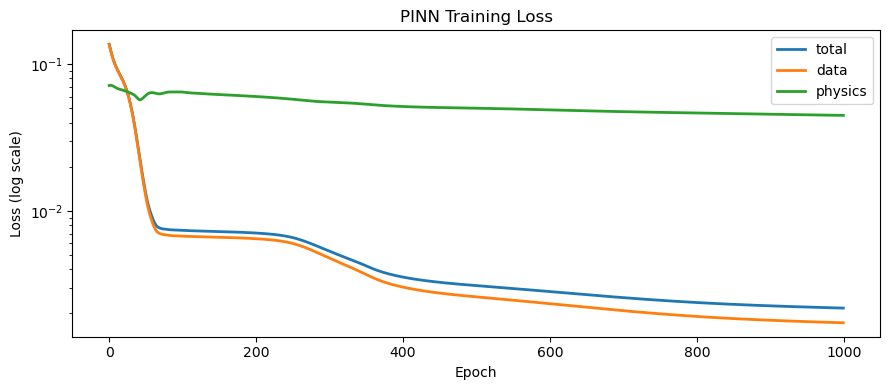

In [41]:
BEST_HIDDEN = [64, 64, 64]
BEST_LR     = 0.001
BEST_LAM    = 0.01
BEST_ACTIVATION = 'tanh'

num_epochs = 1000
patience_val = 100
print("Training PINN...")
model, loss_history, ode_params = train_pinn(
    hidden=BEST_HIDDEN, lr=BEST_LR, lam=BEST_LAM, activation=BEST_ACTIVATION,
    epochs=num_epochs, patience=patience_val, print_every=100
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(loss_history['total'],   label='total',   lw=2)
ax.semilogy(loss_history['data'],    label='data',    lw=2)
ax.semilogy(loss_history['physics'], label='physics', lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log scale)')
ax.set_title('PINN Training Loss')
ax.legend()
plt.tight_layout()
plt.show()


In [37]:
# BEST_HIDDEN = [64, 64, 64]
# BEST_LR     = 0.0001
# BEST_LAM    = 0.1
# BEST_ACTIVATION = 'tanh'

# num_epochs = 5000
# patience_val = 500
# print("Training PINN...")
# model, loss_history, ode_params = train_pinn(
#     hidden=BEST_HIDDEN, lr=BEST_LR, lam=BEST_LAM, activation=BEST_ACTIVATION,
#     epochs=5000, patience=500, print_every=100
# )

# fig, ax = plt.subplots(figsize=(9, 4))
# ax.semilogy(loss_history['total'],   label='total',   lw=2)
# ax.semilogy(loss_history['data'],    label='data',    lw=2)
# ax.semilogy(loss_history['physics'], label='physics', lw=2)
# ax.set_xlabel('Epoch')
# ax.set_ylabel('Loss (log scale)')
# ax.set_title('PINN Training Loss')
# ax.legend()
# plt.tight_layout()
# plt.show()


### Evaluate and plot

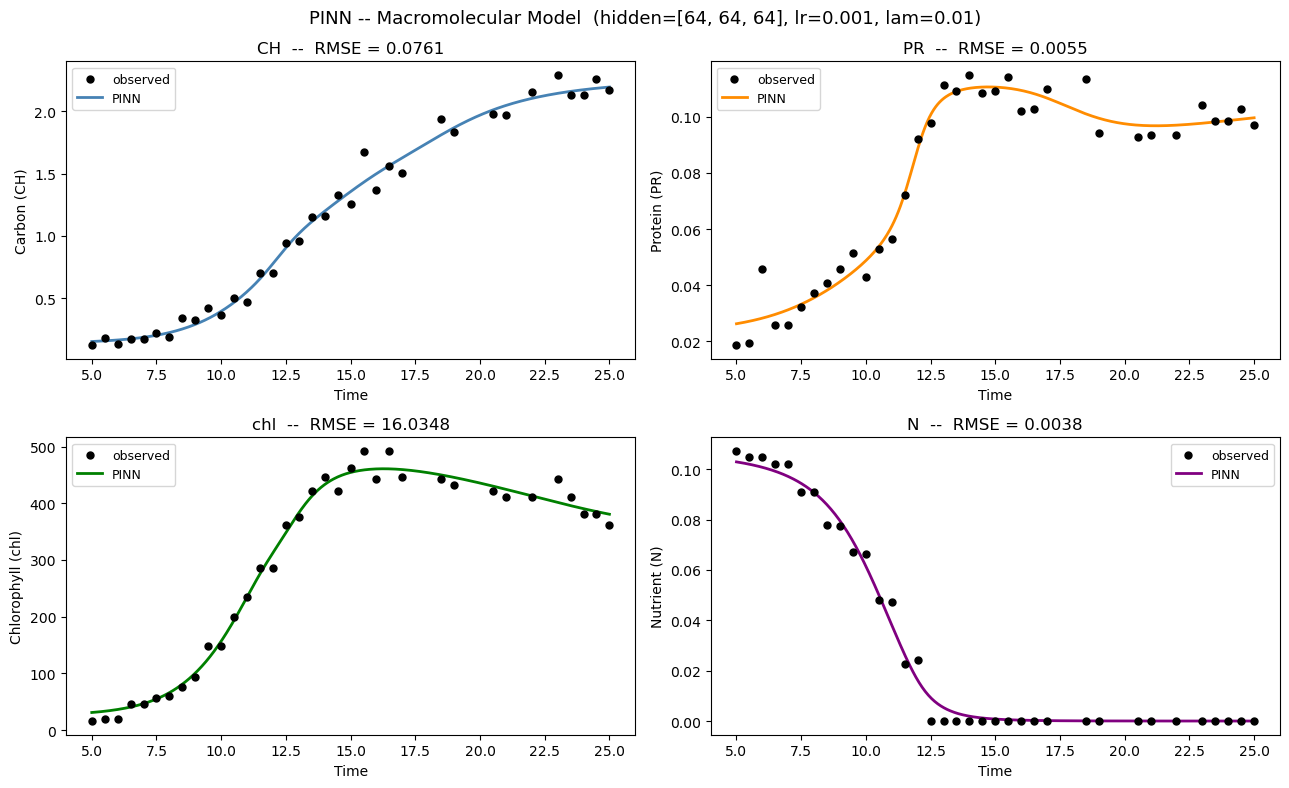

In [42]:
t_fine     = tf.constant(np.linspace(0, 1, 500, dtype=np.float32)[:, None])
t_fine_raw = t_fine.numpy().flatten() * (t_max - t_min) + t_min

pred_obs  = model(t_tensor).numpy()
pred_fine = model(t_fine).numpy()

def unscale(arr, col):
    vmin, vmax = scalers[col]
    return arr * (vmax - vmin) + vmin

fig, axs = plt.subplots(2, 2, figsize=(13, 8))
for idx, (col, label, color) in enumerate(zip(
        state_names, state_labels, colors)):
    ax = axs.flat[idx]
    obs_phys  = dat[col].values
    pred_phys = unscale(pred_fine[:, idx], col)

    ax.scatter(dat['t'], obs_phys, color='black', s=25, zorder=5, label='observed')
    ax.plot(t_fine_raw, pred_phys, lw=2, color=color, label='PINN')

    rmse = np.sqrt(np.mean((obs_phys - unscale(pred_obs[:, idx], col))**2))
    ax.set_ylabel(label)
    ax.set_xlabel('Time')
    ax.set_title(f'{col}  --  RMSE = {rmse:.4f}')
    ax.legend(fontsize=9)

fig.suptitle(f'PINN -- Macromolecular Model  '
             f'(hidden={BEST_HIDDEN}, lr={BEST_LR}, lam={BEST_LAM})',
             fontsize=13)
plt.tight_layout()
plt.show()


### Print Learned Parameters

In [43]:
param_names = ['mu', 'KN', 'CHsyn', 'm_ex', 'R_ex', 'tau', 'b', 'CNpro']

print("Learned ODE parameters:")
for name, var in zip(param_names, ode_params):
    prior = default_params[name]
    print(f"  {name:6s} = {var.numpy():.5f}  (prior mean: {prior})")


Learned ODE parameters:
  mu     = 0.31232  (prior mean: 0.3)
  KN     = 0.00878  (prior mean: 0.002)
  CHsyn  = 5.69688  (prior mean: 5.0)
  m_ex   = 9.16377  (prior mean: 10.0)
  R_ex   = 13.55214  (prior mean: 13.0)
  tau    = 10.90949  (prior mean: 10.0)
  b      = 0.70862  (prior mean: 0.05)
  CNpro  = 5.46555  (prior mean: 6.6)


## 12. $\lambda$ sensitivity analysis

The $\lambda$ hyperparameter controls the tradeoff between data fidelity and
physical consistency. Here we train four models with different $\lambda$ values
and compare their trajectories and MSE values.

- **$\lambda \to 0$**: pure data fitting, no physics constraint
- **$\lambda \to \infty$**: physics dominates, data may be ignored
- **Intermediate $\lambda$**: the PINN regime, where both contribute

In [44]:
lam_values = [1.0, 0.1, 0.01, 0.001]
lam_models = {}
param_names = ['mu', 'KN', 'CHsyn', 'm_ex', 'R_ex', 'tau', 'b', 'CNpro']

for lam in lam_values:
    print(f"\nTraining lambda = {lam}...")
    mdl, _, ode_p = train_pinn(hidden=BEST_HIDDEN, lr=BEST_LR, lam=lam,
                               activation=BEST_ACTIVATION,
                               epochs=num_epochs, patience=patience_val, print_every=999999)
    pred_f = mdl(t_fine).numpy()
    pred_o = mdl(t_tensor).numpy()
    mse_per_var = {
        col: np.mean((data_scaled[col] - pred_o[:, i])**2)
        for i, col in enumerate(state_names)
    }
    lam_models[lam] = {
        'pred_fine': pred_f,
        'mse': mse_per_var,
        'params': {name: v.numpy() for name, v in zip(param_names, ode_p)}
    }
    print(f"  lambda={lam}  " + "  ".join(
        f"{col}={mse_per_var[col]:.4f}" for col in state_names))
    print(f"  " + "  ".join(
        f"{name}={v.numpy():.4f}" for name, v in zip(param_names, ode_p)))



Training lambda = 1.0...
  lambda=1.0  CH=0.0232  PR=0.0145  chl=0.0082  N=0.0043
  mu=0.3358  KN=0.0246  CHsyn=5.1250  m_ex=9.8672  R_ex=13.6055  tau=10.8991  b=0.9954  CNpro=5.4932

Training lambda = 0.1...
  lambda=0.1  CH=0.0018  PR=0.0040  chl=0.0013  N=0.0014
  mu=0.3138  KN=0.0104  CHsyn=5.7649  m_ex=9.1462  R_ex=13.5824  tau=10.9187  b=0.9923  CNpro=5.4571

Training lambda = 0.01...
  lambda=0.01  CH=0.0012  PR=0.0034  chl=0.0011  N=0.0012
  mu=0.3131  KN=0.0095  CHsyn=5.7093  m_ex=9.1578  R_ex=13.5616  tau=10.9247  b=0.7067  CNpro=5.4694

Training lambda = 0.001...
  lambda=0.001  CH=0.0014  PR=0.0038  chl=0.0013  N=0.0013
  mu=0.3112  KN=0.0108  CHsyn=5.7485  m_ex=9.1408  R_ex=13.6764  tau=10.9048  b=0.2242  CNpro=5.5691


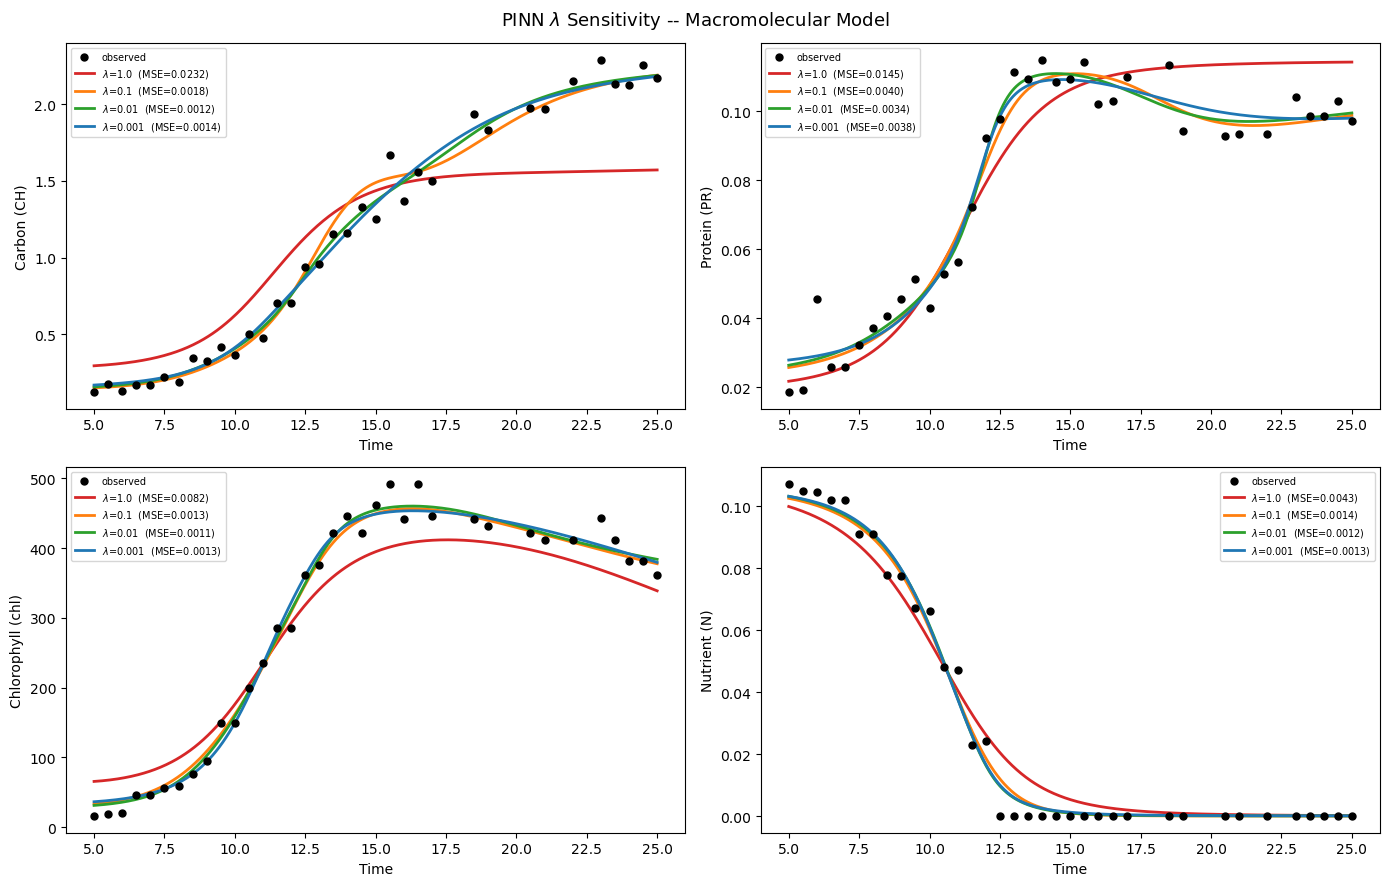

In [45]:
fig, axs = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
lam_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

for idx, (col, label) in enumerate(zip(state_names, state_labels)):
    ax = axs.flat[idx]
    ax.scatter(dat['t'], dat[col], color='black', s=25,
               zorder=5, label='observed')
    for lam, lc in zip(lam_values, lam_colors):
        pred_phys = unscale(lam_models[lam]['pred_fine'][:, idx], col)
        mse_val = lam_models[lam]['mse'][col]
        ax.plot(t_fine_raw, pred_phys, lw=2, color=lc,
                label=f'$\\lambda$={lam}  (MSE={mse_val:.4f})')
    ax.set_ylabel(label)
    ax.set_xlabel('Time')
    ax.legend(fontsize=7)

fig.suptitle('PINN $\\lambda$ Sensitivity -- Macromolecular Model', fontsize=13)
plt.tight_layout()
plt.show()


In [46]:
param_df = pd.DataFrame({lam: lam_models[lam]['params'] for lam in lam_values})
print("Learned parameters by lambda:")
print(param_df.to_string(float_format='%.4f'))


Learned parameters by lambda:
        1.000   0.100   0.010   0.001
mu     0.3358  0.3138  0.3131  0.3112
KN     0.0246  0.0104  0.0095  0.0108
CHsyn  5.1250  5.7649  5.7093  5.7485
m_ex   9.8672  9.1462  9.1578  9.1408
R_ex  13.6055 13.5824 13.5616 13.6764
tau   10.8991 10.9187 10.9247 10.9048
b      0.9954  0.9923  0.7067  0.2242
CNpro  5.4932  5.4571  5.4694  5.5691
